### 1. Data loading

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

control_df = pd.read_csv("./control_group.csv", sep=";")
test_df = pd.read_csv("./test_group.csv", sep=";")


control_df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
test_df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


### 2. Data preparation

The control group dataset contains a day when advertising costs were recorded, but there are no statistics for this day at all, indicating a technical failure. Decision is to remove this day from the control and test groups.

In [109]:
control_clean = control_df.dropna(subset=["# of Purchase"]).copy()
test_clean = test_df.drop(4).copy()

### 3. Data aggregation

In [110]:
df = pd.concat([control_clean, test_clean], ignore_index=True)

In [111]:
agg_df = df.drop("Date", axis=1).copy().groupby("Campaign Name", as_index=False).sum()
agg_df

,Campaign Name,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,66818,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0
1,Test Campaign,74595,2123249.0,1509609.0,175107.0,70463.0,54882.0,25490.0,14869.0


### 4. Metrics calculation

In [112]:
pairs = [
        ("# of Website Clicks", "# of Impressions"),
        ("# of Searches", "# of Website Clicks"),
        ("# of View Content", "# of Searches"),
        ("# of Add to Cart", "# of View Content"),
        ("# of Purchase", "# of Add to Cart"),
    ]

def stage_ratios(row):
    ratios = {}
    for num, den in pairs:
        ratios[f"{num} / {den}"] = (row[num] / row[den])
    return pd.Series(ratios)

ratio_df = agg_df.join(agg_df.apply(stage_ratios, axis=1))
ratio_df

,Campaign Name,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,# of Website Clicks / # of Impressions,# of Searches / # of Website Clicks,# of View Content / # of Searches,# of Add to Cart / # of View Content,# of Purchase / # of Add to Cart
0,Control Campaign,66818,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0,0.048565,0.417477,0.875066,0.668795,0.402149
1,Test Campaign,74595,2123249.0,1509609.0,175107.0,70463.0,54882.0,25490.0,14869.0,0.082471,0.402400,0.778877,0.464451,0.583327


In [113]:
ratio_long = ratio_df.melt(
    id_vars=["Campaign Name"],
    value_vars=[column for column in ratio_df.columns if "/" in column],
    var_name="Ratio",
    value_name="Rate"
)

ratio_long

,Campaign Name,Ratio,Rate
0,Control Campaign,# of Website Clicks / # of Impressions,0.048565
1,Test Campaign,# of Website Clicks / # of Impressions,0.082471
2,Control Campaign,# of Searches / # of Website Clicks,0.417477
3,Test Campaign,# of Searches / # of Website Clicks,0.402400
4,Control Campaign,# of View Content / # of Searches,0.875066
5,Test Campaign,# of View Content / # of Searches,0.778877
6,Control Campaign,# of Add to Cart / # of View Content,0.668795
7,Test Campaign,# of Add to Cart / # of View Content,0.464451
8,Control Campaign,# of Purchase / # of Add to Cart,0.402149
9,Test Campaign,# of Purchase / # of Add to Cart,0.583327


### 5. Funnel visualization

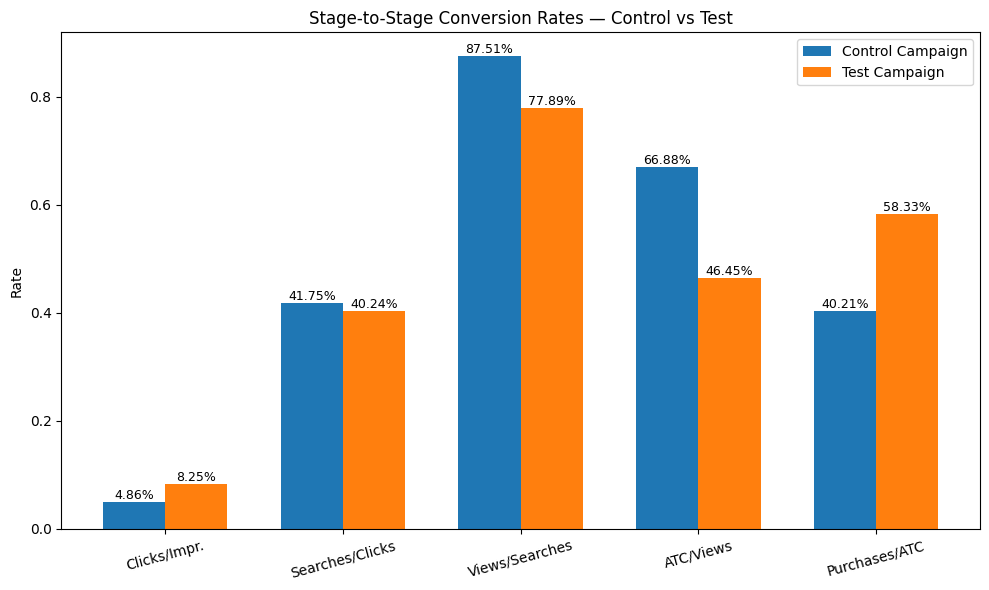

In [114]:
plt.figure(figsize=(10, 6))
x = np.arange(len(pairs))
width = 0.35

control_rates = ratio_long[ratio_long["Campaign Name"]=="Control Campaign"]["Rate"].values
test_rates = ratio_long[ratio_long["Campaign Name"]=="Test Campaign"]["Rate"].values

plt.bar(x - width/2, control_rates, width, label="Control Campaign")
plt.bar(x + width/2, test_rates, width, label="Test Campaign")

for xi, v in zip(x - width/2, control_rates):
    if pd.notna(v):
        plt.text(xi, v, f"{v:.2%}", ha="center", va="bottom", fontsize=9)
for xi, v in zip(x + width/2, test_rates):
    if pd.notna(v):
        plt.text(xi, v, f"{v:.2%}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, ["Clicks/Impr.", "Searches/Clicks", "Views/Searches", "ATC/Views", "Purchases/ATC"], rotation=15)
plt.ylabel("Rate")
plt.title("Stage-to-Stage Conversion Rates — Control vs Test")
plt.legend()
plt.tight_layout()
plt.show()

### 6. Conclusion

As already revealed in the previous task, the new advertisement has a significantly higher click-through rate, but then, due to unknown reasons (such as the advertisement not meeting its promises or problems with the site itself), potential buyers are lost on the site itself in the test group much faster than in the control group. It is necessary to investigate the reasons for this drop-out.

An interesting fact that was overlooked during the previous analysis is that users in the test group convert significantly better from cart to purchase. The reasons for this phenomenon are unclear. Perhaps customer segmentation could help.